Generating final data

In [78]:
import pandas as pd
import numpy as np
import random as rn
import matplotlib.pyplot as plt

In [79]:
num_samples=10000

Stroke severity

In [80]:
df_s=pd.read_csv("stroke_severity.csv")
s=df_s["stroke_severity"]
np.random.seed(42)
W1=np.random.choice(s,10000,p=df_s["count"])

In [81]:
SS_mild=(W1<5).astype(int)
SS_moderate=((W1>=5)&(W1<=30)).astype(int)
SS_severe=(W1>30).astype(int)

In [82]:
df_stroke_severity=pd.DataFrame([W1,SS_mild,SS_moderate,SS_severe], index=["Stroke severity","Mild Stroke","Moderate Stroke","Severe Stroke"])
df_stroke_severity=df_stroke_severity.T
df_stroke_severity

,Stroke severity,Mild Stroke,Moderate Stroke,Severe Stroke
0,5.0,0.0,1.0,0.0
1,25.0,0.0,1.0,0.0
2,13.0,0.0,1.0,0.0
3,9.0,0.0,1.0,0.0
4,3.0,1.0,0.0,0.0
...,...,...,...,...
9995,16.0,0.0,1.0,0.0
9996,21.0,0.0,1.0,0.0
9997,25.0,0.0,1.0,0.0
9998,6.0,0.0,1.0,0.0


Generating age

In [83]:
df_age=pd.read_csv("age_over80.csv")
age=df_age["age_over80"]
np.random.seed(42)
W0=np.random.choice(age,num_samples,p=df_age["count"])

In [84]:
df_age=pd.DataFrame(W0, columns=["Age"])
df_age

,Age
0,0
1,1
2,1
3,0
4,0
...,...
9995,1
9996,1
9997,1
9998,0


Generating 'x' values

In [85]:
np.random.seed(42)
x_values = np.random.uniform(size=num_samples)
x_values = np.round(x_values, 5)

Generating pre-stroke disability for those under 80


In [86]:
df_age_dis = pd.read_csv("combo_ageover80_disability.csv", index_col=0)

df_age_dis.sum()

# Pick out values:
mrs_probs = df_age_dis['0'].values
# Make sure they sum to 1:
mrs_probs = mrs_probs / np.sum(mrs_probs)

mrs_cprobs= np.cumsum(mrs_probs)

s_mrs_cprobs = pd.Series(mrs_cprobs, index=range(len(mrs_cprobs)))

x_inds = np.digitize(x_values, mrs_cprobs, right=True)

df_mrs_u80 = pd.DataFrame(x_inds, columns=["MRS u80"])
df_mrs_u80

,MRS u80
0,0
1,3
2,1
3,0
4,0
...,...
9995,2
9996,2
9997,3
9998,0


NameError: name 'x_mrs' is not defined

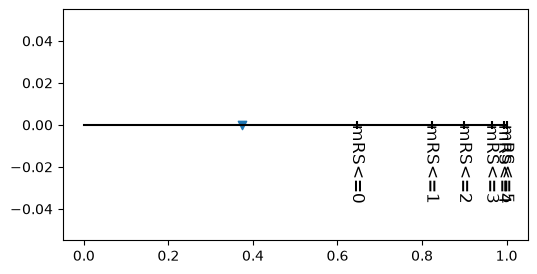

In [88]:
fig, ax = plt.subplots(figsize=(6, 3))

# Basic line:
ax.plot((0, 1), (0, 0), color='k')

# mRS bands:
for mrs, p in enumerate(mrs_cprobs):
    ax.scatter(p, 0, marker='|', color='k')
    ax.annotate(f'mRS<={mrs}', (p, 0), va='top', ha='center', fontsize=12, rotation=-90)

# Generated x:
for i, x in enumerate(x_values[:10]):
    # Draw marker:
    ax.scatter(x, 0.0, marker='v')
    # Label with assigned mRS:
    mrs = x_mrs.iloc[i]
    ax.annotate(mrs, (x, 0.0), va='bottom', ha='center')

ax.yaxis.set_visible(False)
plt.show()

Generating pre-stroke disability for those over 80

In [89]:
df_age_dis = pd.read_csv("combo_ageover80_disability.csv", index_col=0)

In [90]:
df_age_dis.sum()

0    0.6087
1    0.3913
dtype: float64

In [91]:
# Pick out values:
mrs_probs = df_age_dis['1'].values
# Make sure they sum to 1:
mrs_probs = mrs_probs / np.sum(mrs_probs)
mrs_probs

array([0.29685663, 0.20107335, 0.15244058, 0.21196013, 0.11259903,
       0.02507028])

In [92]:
mrs_cprobs= np.cumsum(mrs_probs)
mrs_cprobs

array([0.29685663, 0.49792998, 0.65037056, 0.86233069, 0.97492972,
       1.        ])

In [93]:
s_mrs_cprobs = pd.Series(mrs_cprobs, index=range(len(mrs_cprobs)))

s_mrs_cprobs

0    0.296857
1    0.497930
2    0.650371
3    0.862331
4    0.974930
5    1.000000
dtype: float64

In [94]:
x_inds = np.digitize(x_values, mrs_cprobs, right=True)

x_inds

array([1, 4, 3, ..., 4, 1, 0], shape=(10000,))

In [95]:
df_mrs_o80 = pd.DataFrame(x_inds, columns=["MRS o80"])
df_mrs_o80

,MRS o80
0,1
1,4
2,3
3,2
4,0
...,...
9995,3
9996,4
9997,4
9998,1


Plotting

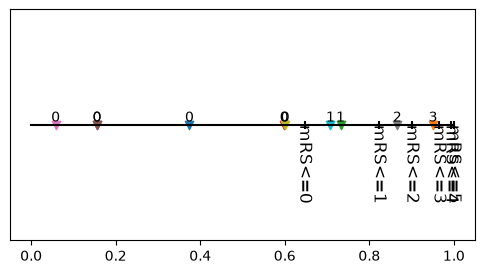

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))

# Basic line:
ax.plot((0, 1), (0, 0), color='k')

# mRS bands:
for mrs, p in enumerate(mrs_cprobs):
    ax.scatter(p, 0, marker='|', color='k')
    ax.annotate(f'mRS<={mrs}', (p, 0), va='top', ha='center', fontsize=12, rotation=-90)

# Generated x:
for i, x in enumerate(x_values[:10]):
    # Draw marker:
    ax.scatter(x, 0.0, marker='v')
    # Label with assigned mRS:
    mrs = x_mrs.iloc[i]
    ax.annotate(mrs, (x, 0.0), va='bottom', ha='center')

ax.yaxis.set_visible(False)
plt.show()

Making a dtaaframe that takes correct MRS values

In [96]:
df_age_prior_disability=pd.concat([df_age, df_mrs_u80, df_mrs_o80],axis=1)
df_age_prior_disability["MRS"]=df_age_prior_disability["MRS u80"].copy()
mask=df_age_prior_disability["Age"]>0
df_age_prior_disability.loc[mask,"MRS"]=df_age_prior_disability.loc[mask,"MRS o80"].copy()
df_age_prior_disability=df_age_prior_disability.drop(["MRS u80","MRS o80"],axis=1)

df_age_prior_disability["x_values"]=x_values
df_age_prior_disability

,Age,MRS,x_values
0,0,0,0.37454
1,1,4,0.95071
2,1,3,0.73199
3,0,0,0.59866
4,0,0,0.15602
...,...,...,...
9995,1,3,0.85766
9996,1,4,0.89751
9997,1,4,0.94671
9998,0,0,0.39749


Converting to utility values

In [97]:
util_scores = dict(zip(range(7), [0.95, 0.93, 0.83, 0.62, 0.42, 0.11, 0.0]))

util_scores

{0: 0.95, 1: 0.93, 2: 0.83, 3: 0.62, 4: 0.42, 5: 0.11, 6: 0.0}

In [98]:
df_age_prior_disability["Utility"]=df_age_prior_disability["MRS"].map(util_scores)
df_age_prior_disability

,Age,MRS,x_values,Utility
0,0,0,0.37454,0.95
1,1,4,0.95071,0.42
2,1,3,0.73199,0.62
3,0,0,0.59866,0.95
4,0,0,0.15602,0.95
...,...,...,...,...
9995,1,3,0.85766,0.62
9996,1,4,0.89751,0.42
9997,1,4,0.94671,0.42
9998,0,0,0.39749,0.95


A fib and Anticoagulation

In [99]:
df_af_a=pd.read_csv("combo_anticoag_afib.csv", index_col="afib_anticoagulant")
df_af_a

,0,1
afib_anticoagulant,,
0,0.76744,0.06481
1,0.03264,0.13511


In [101]:
q=df_af_a.loc[0,"0"]
r=df_af_a.loc[0,"1"]
s=df_af_a.loc[1,"0"]
t=df_af_a.loc[1,"1"]

q1=q/(q+s)
s1=s/(q+s)

r1=r/(r+t)
t1=t/(r+t)

In [102]:
num_rows = 10000
p = t+r
np.random.seed(42)
f1 = np.random.binomial(1, p, num_rows)


f2=np.full(num_rows,42)
inds_f1_0 = np.where(f1 == 0)

num_f1_0 = len(inds_f1_0[0])

inds_f1_1= np.where(f1==1)
num_f1_1= len(inds_f1_1[0])

f2_vals = np.random.choice([0, 1], num_f1_0, p=[q1,s1])
f2[inds_f1_0] = f2_vals

f1_vals=np.random.choice([0, 1], num_f1_1, p=[r1,t1])
f2[inds_f1_1]=f1_vals

In [103]:
df_b=pd.Series(f1)
df_c=pd.Series(f2)

In [104]:
df_af_anticoag=pd.concat([df_b,df_c], axis=1)
df_af_anticoag.columns=["AF_patients","AF_patients_on_anticoagulants"]
df_af_anticoag

,AF_patients,AF_patients_on_anticoagulants
0,0,0
1,1,1
2,0,0
3,0,0
4,0,0
...,...,...
9995,1,0
9996,1,1
9997,1,0
9998,0,0


Onset during sleep and precise onset known

In [105]:
df_sp=pd.read_csv("combo_sleep_precise.csv", index_col="precise_onset_known")
df_sp

,0,1
precise_onset_known,,
0,0.33568,0.04340
1,0.62091,0.00001


In [106]:
u=df_sp.loc[0,"0"]#0.33568
v=df_sp.loc[0,"1"]
w=df_sp.loc[1,"0"]
x=df_sp.loc[1,"1"]
#no quote marks for rows

u1=u/(u+w)
w1=w/(u+w)

v1=v/(v+x)
x1=x/(v+x)

In [107]:
num_rows = 10000
# Pick feature 1 at random:
p = v+x
np.random.seed(42)
f1 = np.random.binomial(1, p, num_rows)

# Start with all feature 2 as zero:
#f2 = np.zeros(num_rows)
f2=np.full(num_rows,42)

# Update feature 2 depending on feature 1.
# Pick out where feature 1 is zero:
inds_f1_0 = np.where(f1 == 0)

# How many times is feature 1 zero?
num_f1_0 = len(inds_f1_0[0])

inds_f1_1= np.where(f1==1)
num_f1_1= len(inds_f1_1[0])

# Generate new vals for feature 2 when feature 1 is zero:
f2_vals = np.random.choice([0, 1], num_f1_0, p=[u1,w1])
# Update feature 2 with the new values:
f2[inds_f1_0] = f2_vals

f1_vals=np.random.choice([0, 1], num_f1_1, p=[v1,x1])
f2[inds_f1_1]=f1_vals

In [108]:
df_d=pd.Series(f1)
df_e=pd.Series(f2)

In [109]:
df_sleep_precise_onset=pd.concat([df_d,df_e], axis=1)
df_sleep_precise_onset.columns=["Onset_during_sleep","Precise_onset_known"]
df_sleep_precise_onset

,Onset_during_sleep,Precise_onset_known
0,0,1
1,0,0
2,0,0
3,0,1
4,0,1
...,...,...
9995,0,1
9996,0,1
9997,0,1
9998,0,1


ATST and stroke team

In [110]:
df_as=pd.read_csv("arrival_to_scan_time_stats_by_stroke_team.csv", index_col="stats")

In [111]:
df_b=pd.read_csv("stroke_team.csv")
c=df_b["stroke_team"]
np.random.seed(42)
patient_population=np.random.choice(c,num_samples,p=df_b["count"])

pp=pd.Series(patient_population)

In [112]:
q=df_as.loc["mu_for_lognorm", "0"]
r=df_as.loc["sigma_for_lognorm", "0"]

f1 = np.random.default_rng()
t_gen = f1.lognormal(q, r, size=num_samples)

team_names=df_as.columns
f3=np.full(num_samples,42)

for i in team_names:
    m=df_as.loc["mu_for_lognorm", i]
    n=df_as.loc["sigma_for_lognorm", i]

    if int(i) in pp.value_counts().index:
        s=pp.value_counts()[int(i)]
    else:
        s=0

    f2 = np.random.default_rng()
    n_gen = f2.lognormal(m, n, size=s)

    inds_f2_0 = np.where(patient_population == int(i))
    f3[inds_f2_0] = n_gen

In [113]:
df_stroke_team_ATST=pd.DataFrame([pp, f3]).T
df_stroke_team_ATST.columns=["Stroke team","Arrival to scan time"]
df_stroke_team_ATST

,Stroke team,Arrival to scan time
0,64,41
1,42,15
2,12,35
3,5,87
4,79,274
...,...,...
9995,63,14
9996,47,35
9997,95,23
9998,26,134


In [114]:
df_final=pd.concat([df_stroke_severity,df_age_prior_disability,df_af_anticoag,df_sleep_precise_onset,df_stroke_team_ATST], axis=1)
df_final

,Stroke severity,Mild Stroke,Moderate Stroke,Severe Stroke,Age,MRS,x_values,Utility,AF_patients,AF_patients_on_anticoagulants,Onset_during_sleep,Precise_onset_known,Stroke team,Arrival to scan time
0,5.0,0.0,1.0,0.0,0,0,0.37454,0.95,0,0,0,1,64,41
1,25.0,0.0,1.0,0.0,1,4,0.95071,0.42,1,1,0,0,42,15
2,13.0,0.0,1.0,0.0,1,3,0.73199,0.62,0,0,0,0,12,35
3,9.0,0.0,1.0,0.0,0,0,0.59866,0.95,0,0,0,1,5,87
4,3.0,1.0,0.0,0.0,0,0,0.15602,0.95,0,0,0,1,79,274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,16.0,0.0,1.0,0.0,1,3,0.85766,0.62,1,0,0,1,63,14
9996,21.0,0.0,1.0,0.0,1,4,0.89751,0.42,1,1,0,1,47,35
9997,25.0,0.0,1.0,0.0,1,4,0.94671,0.42,1,0,0,1,95,23
9998,6.0,0.0,1.0,0.0,0,0,0.39749,0.95,0,0,0,1,26,134


In [115]:
df_final.to_csv("final_10_08.csv")